In [ ]:
# DAY 12 - CELL 1
# Connect Google Drive and set dataset path

import os
import json

from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

print("Dataset path:", BASE_PATH)
print("Path exists:", os.path.exists(BASE_PATH))

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Underwater-Image-Data-set-main
Path exists: True


In [ ]:
# DAY 12 - CELL 2
# Find complete Input-Target pairs

pairs = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:

        if "_input" in file.lower() and file.lower().endswith((".png", ".jpg", ".jpeg")):

            input_path = os.path.join(root, file)
            sample_id = file.rsplit("_input", 1)[0]

            target_path = os.path.join(
                root,
                sample_id + "_target.png"
            )

            if os.path.exists(target_path):
                pairs.append((input_path, target_path))

print("Total Input-Target pairs:", len(pairs))

Total Input-Target pairs: 1233


Total pairs: 1233

Pair 1
Input : img 138_input.png
Target: img 138_target.png

Pair 2
Input : img 78_input.png
Target: img 78_target.png

Pair 3
Input : img 115_input.png
Target: img 115_target.png

Pair 4
Input : img 56_input.png
Target: img 56_target.png

Pair 5
Input : img 53_input.png
Target: img 53_target.png


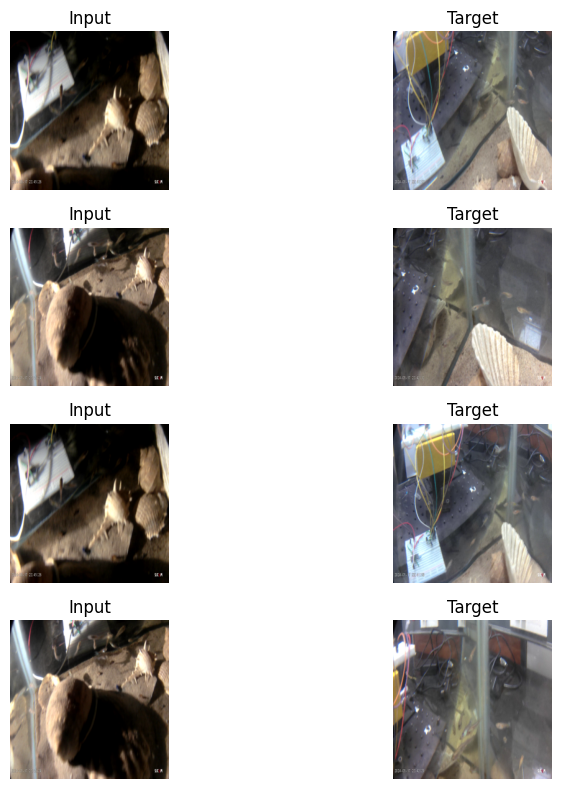

In [ ]:
# DAY 12 - CELL 3
# Review sample Input-Target pairs

from PIL import Image
import matplotlib.pyplot as plt

print("Total pairs:", len(pairs))

for i in range(min(5, len(pairs))):
    input_path, target_path = pairs[i]

    print("\nPair", i + 1)
    print("Input :", os.path.basename(input_path))
    print("Target:", os.path.basename(target_path))

plt.figure(figsize=(10, 8))

for i in range(min(4, len(pairs))):
    input_path, target_path = pairs[i]

    input_image = Image.open(input_path)
    target_image = Image.open(target_path)

    plt.subplot(4, 2, i * 2 + 1)
    plt.imshow(input_image)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(4, 2, i * 2 + 2)
    plt.imshow(target_image)
    plt.axis("off")
    plt.title("Target")

plt.tight_layout()
plt.show()

In [ ]:
# DAY 12 - CELL 4
# Create Train / Validation / Test splits

from sklearn.model_selection import train_test_split

train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42
)

print("Training pairs   :", len(train_pairs))
print("Validation pairs :", len(val_pairs))
print("Testing pairs    :", len(test_pairs))
print("Total pairs      :", len(train_pairs) + len(val_pairs) + len(test_pairs))

Training pairs   : 863
Validation pairs : 185
Testing pairs    : 185
Total pairs      : 1233


In [ ]:
# DAY 12 - CELL 5
# Check for overlap between Train, Validation and Test sets

train_inputs = set(pair[0] for pair in train_pairs)
val_inputs = set(pair[0] for pair in val_pairs)
test_inputs = set(pair[0] for pair in test_pairs)

train_val = train_inputs.intersection(val_inputs)
train_test = train_inputs.intersection(test_inputs)
val_test = val_inputs.intersection(test_inputs)

print("Train-Val overlap :", len(train_val))
print("Train-Test overlap:", len(train_test))
print("Val-Test overlap  :", len(val_test))

if len(train_val) == 0 and len(train_test) == 0 and len(val_test) == 0:
    print("\nNo overlap found. Split is leakage-safe.")
else:
    print("\nOverlap found. Check the dataset split.")

Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0

No overlap found. Split is leakage-safe.


In [ ]:
# DAY 12 - CELL 6
# Review preprocessing configuration

image_size = (256, 256)
normalization_range = (0, 1)
channels = 3

print("========== PREPROCESSING REVIEW ==========")
print("Image size       :", image_size)
print("Image channels   :", channels, "(RGB)")
print("Normalization    :", "Pixel values divided by 255")
print("Final pixel range:", normalization_range)
print("Augmentation     :", "Not applied")

========== PREPROCESSING REVIEW ==========
Image size       : (256, 256)
Image channels   : 3 (RGB)
Normalization    : Pixel values divided by 255
Final pixel range: (0, 1)
Augmentation     : Not applied


In [ ]:
# DAY 12 - CELL 7
# Freeze Dataset V1

dataset_v1 = {
    "version": "Dataset V1",
    "image_size": "256x256",
    "image_type": "RGB",
    "normalization": "0-1",
    "train_split": "70%",
    "validation_split": "15%",
    "test_split": "15%",
    "augmentation": "Not applied",
    "leakage_check": "Passed",
    "mentor_corrections": "None"
}

freeze_path = os.path.join(
    BASE_PATH,
    "Dataset_V1_final_config.json"
)

with open(freeze_path, "w") as f:
    json.dump(dataset_v1, f, indent=4)

print("================================")
print("DATASET V1 FROZEN")
print("================================")
print("Version              :", dataset_v1["version"])
print("Image size           :", dataset_v1["image_size"])
print("Image type           :", dataset_v1["image_type"])
print("Normalization        :", dataset_v1["normalization"])
print("Train / Val / Test   :", "70% / 15% / 15%")
print("Augmentation         :", dataset_v1["augmentation"])
print("Leakage check        :", dataset_v1["leakage_check"])
print("Mentor corrections   :", dataset_v1["mentor_corrections"])
print("Configuration saved  :", freeze_path)

DATASET V1 FROZEN
Version              : Dataset V1
Image size           : 256x256
Image type           : RGB
Normalization        : 0-1
Train / Val / Test   : 70% / 15% / 15%
Augmentation         : Not applied
Leakage check        : Passed
Mentor corrections   : None
Configuration saved  : /content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1_final_config.json
